In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, morphology, util
from scipy.ndimage import convolve
from skimage.morphology import binary_dilation, disk, thin
from skimage import io, util
import cv2

In [2]:
def show_thickened_image(path):
    # Load image (binary or grayscale)
    img = io.imread(path, as_gray=True)
    
    # Ensure binary image (important!)
    img = img > 0.5   # foreground = True
    
    # Thinning
    thinned = thin(img)
    
    # Thickening (dual of thinning)
    thickened = img & (~thinned)
    
    # Difference (what was removed by thinning / added by thickening)
    difference = img ^ thinned
    
    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    axes[1].imshow(thinned, cmap="gray")
    axes[1].set_title("Thinned (Skeleton)")
    axes[1].axis("off")
    
    axes[2].imshow(thickened, cmap="gray")
    axes[2].set_title("Thickened")
    axes[2].axis("off")
    
    axes[3].imshow(difference, cmap="gray")
    axes[3].set_title("Difference")
    axes[3].axis("off")
    
    plt.tight_layout()
    plt.show()


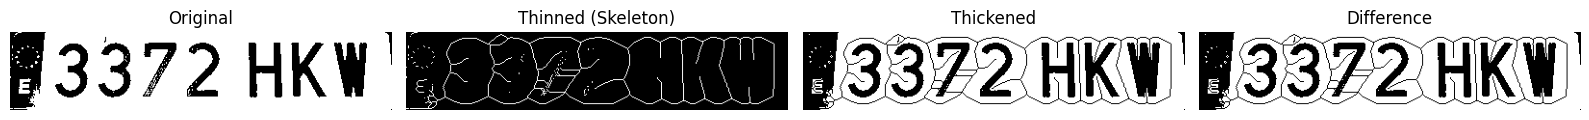

In [4]:
show_thickened_image('./vehicle_plate.jpeg')

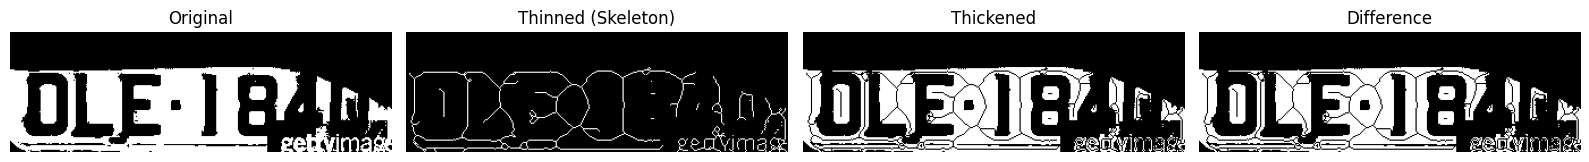

In [5]:
show_thickened_image('./plate_2.jpg')

/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_37067/3650124516.py:7: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  selem = morphology.square(3)
/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_37067/3650124516.py:9: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  thickened = morphology.binary_dilation(binary, selem)
/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_37067/3650124516.py:10: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  thickened = morphology.binary_closing(thickened, selem)
/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_37067/3650124516.py:34: FutureWa

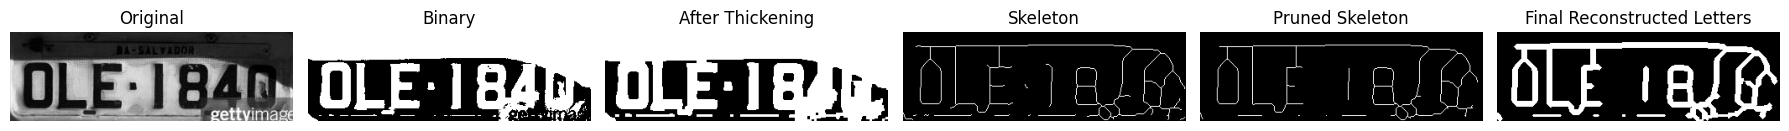

In [9]:
img = io.imread('./plate_2.jpg', as_gray=True)
img = util.img_as_float(img)

thresh = filters.threshold_otsu(img)
binary = img < thresh   # text = True

selem = morphology.square(3)

thickened = morphology.binary_dilation(binary, selem)
thickened = morphology.binary_closing(thickened, selem)

skeleton = morphology.skeletonize(thickened)

kernel = np.array([
    [1,1,1],
    [1,0,1],
    [1,1,1]
])

def prune_skeleton(skel, max_length=8):
    skel = skel.copy()
    for _ in range(max_length):
        neighbors = convolve(skel.astype(int), kernel)
        endpoints = (skel == 1) & (neighbors == 1)
        skel[endpoints] = 0
    return skel


pruned = prune_skeleton(skeleton, max_length=8)

# --- Reconstruction ---
final = pruned.copy()
for _ in range(3):
    final = binary_dilation(final, disk(1))
    final = final & thickened

# --- Convert to uint8 ---
final_uint8 = (final.astype(np.uint8)) * 255

# --- Save ---
cv2.imwrite("plate_final.png", final_uint8)


fig, axes = plt.subplots(1, 6, figsize=(18, 4))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Binary")

axes[2].imshow(thickened, cmap="gray")
axes[2].set_title("After Thickening")

axes[3].imshow(skeleton, cmap="gray")
axes[3].set_title("Skeleton")

axes[4].imshow(pruned, cmap="gray")
axes[4].set_title("Pruned Skeleton")

axes[5].imshow(final, cmap="gray")
axes[5].set_title("Final Reconstructed Letters")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()



/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_37067/341574755.py:7: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  selem = morphology.square(3)
/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_37067/341574755.py:9: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  thickened = morphology.binary_dilation(binary, selem)
/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_37067/341574755.py:10: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  thickened = morphology.binary_closing(thickened, selem)
/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_37067/341574755.py:34: FutureWarnin

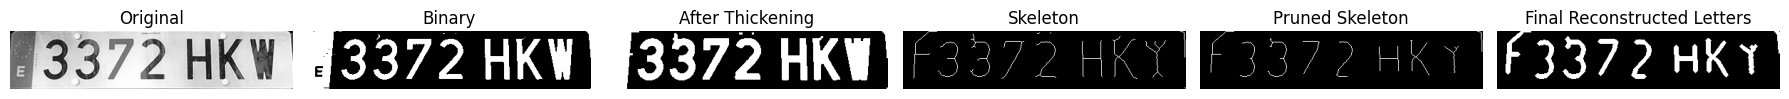

In [10]:
img = io.imread('./vehicle_plate.jpeg', as_gray=True)
img = util.img_as_float(img)

thresh = filters.threshold_otsu(img)
binary = img < thresh   # text = True

selem = morphology.square(3)

thickened = morphology.binary_dilation(binary, selem)
thickened = morphology.binary_closing(thickened, selem)

skeleton = morphology.skeletonize(thickened)

kernel = np.array([
    [1,1,1],
    [1,0,1],
    [1,1,1]
])

def prune_skeleton(skel, max_length=8):
    skel = skel.copy()
    for _ in range(max_length):
        neighbors = convolve(skel.astype(int), kernel)
        endpoints = (skel == 1) & (neighbors == 1)
        skel[endpoints] = 0
    return skel


pruned = prune_skeleton(skeleton, max_length=8)

# --- Reconstruction ---
final = pruned.copy()
for _ in range(3):
    final = binary_dilation(final, disk(1))
    final = final & thickened

# --- Convert to uint8 ---
final_uint8 = (final.astype(np.uint8)) * 255

# --- Save ---
cv2.imwrite("plate_final_2.png", final_uint8)


fig, axes = plt.subplots(1, 6, figsize=(18, 4))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Binary")

axes[2].imshow(thickened, cmap="gray")
axes[2].set_title("After Thickening")

axes[3].imshow(skeleton, cmap="gray")
axes[3].set_title("Skeleton")

axes[4].imshow(pruned, cmap="gray")
axes[4].set_title("Pruned Skeleton")

axes[5].imshow(final, cmap="gray")
axes[5].set_title("Final Reconstructed Letters")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

